# Embedding-based Trend Analysis in NeurIPS Publication

## 1. Introduction


The Conference on Neural Information Processing Systems (NeurIPS) has grown from a small workshop on connectionist models in 1987 to the world’s largest gathering of machine-learning researchers today.  The size of the yearly proceedings increased from fewer than 70 papers at its inception to more than 3 500 papers in 2023, reflecting both the rapid acceleration of artificial-intelligence research and the expanding scope of the conference itself.  While this growth is a testament to scientific progress, it makes it increasingly difficult to keep track of which topics are emerging, which are maturing, and which may be losing momentum.

This project assembles a longitudinal corpus of 40586 NeurIPS papers spanning the years 1987-2023 and uses that corpus to address two main questions:

1. **Descriptive question** - How have basic publication characteristics such as volume, title length, and abstract length changed over time?
2. **Thematic question** - Which research topics are presently growing fastest and which are stagnating or declining?

To answer the descriptive question we first scrape the official NeurIPS website, harmonise its historical HTML changes, and build a cleaned CSV that contains titles, abstracts, and publication years for every accepted paper.  Simple time-series plots of paper counts and text-length statistics give a high-level view of the conference’s expansion.

The thematic question requires a richer representation of content.  We embed every title-abstract pair with the SPECTER2 scientific-text encoder, reduce the 768-dimensional embeddings to two dimensions with UMAP for visualisation, and cluster them with the density-based algorithm HDBSCAN.  Class-based TF–IDF is then used to derive concise topic labels for each cluster.  For every cluster we model the yearly paper counts using four regression families—ordinary least squares, ridge, random forest, and gradient boosting—and compute the slope of the best-fit line through the model-predicted counts.  A positive slope signals a rising topic, whereas a negative slope indicates decline.  Gradient boosting achieves the lowest out-of-sample root-mean-squared error and is therefore chosen for the final interactive map.

The end product is a GitHub Pages website that hosts:

* a concise, text-based summary of the project;
* an interactive 2-D map where each point is a NeurIPS paper, coloured by the growth rate of its topic cluster;
* downloadable PDF and supporting code that reproduce all figures and tables.

Beyond NeurIPS, the pipeline offers a general recipe for large-scale, time-aware text analysis and can be applied to any research corpus that provides abstracts and publication dates.


## 2. Methods

### 2.1 Data Acquisition
The dataset consists of papers accepted at the Conference on Neural Information Processing Systems (NeurIPS) from 1987 to 2023. Due to structural changes on the NeurIPS website, two distinct web scraping methods were necessary: one approach covering the years 1987 to 2021, and another specifically adapted for 2022 and 2023. Both utilized Python libraries `requests` for fetching webpage content, `BeautifulSoup` for parsing HTML, and `ThreadPoolExecutor` for concurrent requests, significantly improving data retrieval efficiency. The extracted data included paper titles, abstracts, and corresponding publication years, which were then consolidated into CSV files for further analysis.

### 2.2 Data Cleaning and Preparation
After collection, the dataset underwent rigorous cleaning to ensure high data quality and consistency. Entries lacking abstracts or containing insufficient abstracts (fewer than five words) were removed, as these offered limited analytical value. Additionally, supplementary attributes such as abstract and title word counts were computed to identify potential anomalies. This resulted in a final, cleaned dataset comprising approximately 40,000 papers, which served as a reliable basis for subsequent analyses.

### 2.3 Exploratory Analysis
The initial exploratory analysis aimed to reveal overarching publication trends and textual characteristics within NeurIPS papers over time. Utilizing Python libraries such as `pandas`, `matplotlib`, and `seaborn`, we examined temporal patterns in publication counts, abstract lengths, and title lengths. This exploratory step established foundational insights, revealing increases in publication volume and abstract length complexity, guiding our decisions for more advanced analytical methods.

### 2.4 Embedding and Clustering
To deeply understand thematic and semantic structures within NeurIPS papers, we employed embedding-based methods. Specifically, we selected the SPECTER2 model (`allenai/specter2_base`) from Hugging Face Transformers, renowned for effectively capturing semantic nuances of scientific literature. SPECTER2 embeddings are particularly suitable due to their ability to represent research papers in a vector space that closely aligns with citation patterns and topical relevance.

Given the high dimensionality of these embeddings, dimensionality reduction was essential for meaningful visualization and efficient clustering. We chose UMAP (`umap-learn`) for this task due to its effectiveness in preserving local and global structures within data compared to other methods like PCA or t-SNE.

Subsequently, clustering was conducted using HDBSCAN, a density-based algorithm capable of identifying naturally occurring clusters without the need for predefined cluster counts. This allowed the detection of both prominent topics and sparse or outlier papers. To manage identified outliers, we employed a k-nearest neighbors reassignment step, implemented via FAISS, ensuring all papers were meaningfully assigned to a thematic cluster.

For cluster interpretation, noun-based bigrams and unigrams were extracted from texts using Spacy’s NLP pipeline. These n-grams were subsequently ranked within clusters using class-based TF-IDF scores to generate descriptive and interpretable cluster topics.

### 2.5 Trend Modeling and Evaluation
A crucial objective was to quantify how research interests within clusters evolved over time. For this purpose, we selected four distinct regression models: linear regression, ridge regression, random forest, and gradient boosting. Linear and ridge regressions offered straightforward interpretability, capturing linear temporal trends with or without regularization, respectively. Random forest and gradient boosting were selected as robust, non-linear ensemble methods capable of modeling complex, non-linear temporal dynamics.

Each model was trained on historical publication counts per cluster, validated against recent years, and evaluated using R² (explained variance) and Root Mean Squared Error (RMSE) metrics. These evaluation criteria were chosen to comprehensively assess model performance in both accuracy and consistency across clusters. Gradient boosting emerged as the best-performing model due to its higher predictive accuracy and superior handling of nonlinear trends, thus selected as the primary method for further detailed analysis and visualization.

### 2.6 Interactive Visualization
To facilitate intuitive exploration and interpretation of the analyzed results, interactive visualizations were developed using Plotly and the `datamapplot` library. These interactive tools enabled users to explore thematic distributions, inspect topic growth rates, and access detailed metadata interactively, significantly enhancing the interpretability and accessibility of the results.


In [19]:
import requests
from bs4 import BeautifulSoup
from concurrent.futures import ThreadPoolExecutor, as_completed
import pandas as pd

# Base URL for the NeurIPS papers
BASE_URL = "https://papers.nips.cc/paper_files/paper/{year}"

def get_paper_links(year):
    """Fetch all paper links from the NeurIPS proceedings page for a given year."""
    url = BASE_URL.format(year=year)
    response = requests.get(url)
    if response.status_code != 200:
        return []

    soup = BeautifulSoup(response.text, 'html.parser')
    paper_list = soup.find_all('li', class_='none')

    paper_links = []
    for paper in paper_list:
        title = paper.find('a').text
        link = paper.find('a')['href']
        paper_links.append((title, link))

    return paper_links

def get_paper_details(link):
    """Extract the title and abstract from the paper's individual page."""
    base_url = "https://papers.nips.cc"
    paper_url = base_url + link
    response = requests.get(paper_url)
    if response.status_code != 200:
        return None, None

    soup = BeautifulSoup(response.text, 'html.parser')
    title = soup.find('h4').text.strip()
    abstract_section = soup.find('h4', text='Abstract')

    # Extract the abstract, if it exists
    if abstract_section:
        abstract = abstract_section.find_next('p').text.strip()
    else:
        abstract = "No abstract found."

    return title, abstract

def scrape_paper_year(year):
    """Scrape all papers for a specific year."""
    paper_links = get_paper_links(year)
    papers = []

    if not paper_links:
        print(f"No papers found for year {year}")
        return papers

    # Process papers in parallel
    with ThreadPoolExecutor() as executor:
        future_to_paper = {executor.submit(get_paper_details, link): (title, link) for title, link in paper_links}
        for future in as_completed(future_to_paper):
            title, link = future_to_paper[future]
            try:
                paper_title, paper_abstract = future.result()
                if paper_title:
                    papers.append({
                        "year": year,
                        "title": paper_title,
                        "abstract": paper_abstract
                    })
            except Exception as e:
                print(f"Error processing {title}: {e}")

    return papers

def scrape_neurips_papers_parallel(start_year, end_year):
    """Scrape NeurIPS papers from start_year to end_year, extracting titles and abstracts in parallel."""
    all_papers = []

    with ThreadPoolExecutor() as executor:
        futures = [executor.submit(scrape_paper_year, year) for year in range(start_year, end_year + 1)]
        for future in as_completed(futures):
            try:
                year_papers = future.result()
                all_papers.extend(year_papers)
            except Exception as e:
                print(f"Error fetching papers for a year: {e}")

    return all_papers

# Scrape papers from 1987 to 2023
papers = scrape_neurips_papers_parallel(1987, 2023)

# Save results to a CSV file
df = pd.DataFrame(papers)
df.to_csv("neurips_papers_1987_2023_parallel.csv", index=False)

# print("Scraping complete! Data saved to neurips_papers_1987_2023_parallel.csv")


<ipython-input-19-36de9e328455>:37: DeprecationWarning:

The 'text' argument to find()-type methods is deprecated. Use 'string' instead.



No papers found for year 2022
No papers found for year 2023


In [20]:
import requests
from bs4 import BeautifulSoup
from concurrent.futures import ThreadPoolExecutor, as_completed
import pandas as pd

# Base URL for NeurIPS papers
BASE_URL = "https://papers.nips.cc/paper_files/paper/{year}"

def get_paper_links_2022_2023(year):
    """Fetch all paper links from the NeurIPS proceedings page for 2022 and 2023."""
    url = BASE_URL.format(year=year)
    response = requests.get(url)
    if response.status_code != 200:
        return []

    soup = BeautifulSoup(response.text, 'html.parser')
    paper_list = soup.find_all('li', class_=['conference', 'datasets_and_benchmarks'])

    paper_links = []
    for paper in paper_list:
        title = paper.find('a').text
        link = paper.find('a')['href']
        paper_links.append((title, link))

    return paper_links

def get_paper_details_2022_2023(link):
    """Extract the title and abstract from the paper's individual page for 2022 and 2023."""
    base_url = "https://papers.nips.cc"
    paper_url = base_url + link
    response = requests.get(paper_url)
    if response.status_code != 200:
        return None, None

    soup = BeautifulSoup(response.text, 'html.parser')
    title = soup.find('h4').text.strip()
    abstract_section = soup.find('h4', string='Abstract')

    # Extract the abstract, if it exists
    if abstract_section:
        abstract = abstract_section.find_next('p').text.strip()
    else:
        abstract = "No abstract found."

    return title, abstract

def scrape_paper_year_2022_2023(year):
    """Scrape all papers for 2022 and 2023."""
    paper_links = get_paper_links_2022_2023(year)
    papers = []

    if not paper_links:
        print(f"No papers found for year {year}")
        return papers

    # Process papers in parallel
    with ThreadPoolExecutor() as executor:
        future_to_paper = {executor.submit(get_paper_details_2022_2023, link): (title, link) for title, link in paper_links}
        for future in as_completed(future_to_paper):
            title, link = future_to_paper[future]
            try:
                paper_title, paper_abstract = future.result()
                if paper_title:
                    papers.append({
                        "year": year,
                        "title": paper_title,
                        "abstract": paper_abstract
                    })
            except Exception as e:
                print(f"Error processing {title}: {e}")

    return papers

def scrape_neurips_papers_2022_2023():
    """Scrape NeurIPS papers for 2022 and 2023."""
    all_papers = []

    with ThreadPoolExecutor() as executor:
        futures = [executor.submit(scrape_paper_year_2022_2023, year) for year in [2022, 2023]]
        for future in as_completed(futures):
            try:
                year_papers = future.result()
                all_papers.extend(year_papers)
            except Exception as e:
                print(f"Error fetching papers for a year: {e}")

    return all_papers

# Scrape papers for 2022 and 2023
papers_2022_2023 = scrape_neurips_papers_2022_2023()

# Load the existing CSV and concatenate the new data
existing_df = pd.read_csv("neurips_papers_1987_2023_parallel.csv")
new_df = pd.DataFrame(papers_2022_2023)

# Concatenate the new data to the existing dataframe
combined_df = pd.concat([existing_df, new_df], ignore_index=True)

# Save the updated dataframe to a CSV file
combined_df.to_csv("neurips_papers_1987_2023_parallel_updated.csv", index=False)

In [30]:
# import matplotlib.pyplot as plt

# # Load the NeurIPS papers dataset
# df = pd.read_csv("neurips_papers_1987_2023_parallel_updated.csv")

# # Ensure the 'year' column is numeric
# df['year'] = pd.to_numeric(df['year'], errors='coerce')

# # Compute abstract and title lengths
# df['abstract_length'] = df['abstract'].fillna("").str.split().apply(len)
# df['title_length'] = df['title'].fillna("").str.split().apply(len)


# # Explore Possible inappropriate papers by length
# short_texts = df[(df['title_length'] < 2) | (df['abstract_length'] < 5)]

# # Print the results in a nicely formatted markdown table
# print("\n**Titles and Abstracts with Less Than 5 Words:**\n")
# print(short_texts[['title', 'abstract']].to_markdown(index=False))

import pandas as pd
from IPython.display import Markdown, display

# 1 – Load data
df = pd.read_csv("neurips_papers_1987_2023_parallel_updated.csv")
df["year"] = pd.to_numeric(df["year"], errors="coerce")

# 2 – Compute text-length features
df["abstract_length"] = df["abstract"].fillna("").str.split().str.len()
df["title_length"]    = df["title"].fillna("").str.split().str.len()

# 3 – Flag papers with very short titles OR abstracts
short_texts = (
    df.loc[(df["title_length"] < 2) | (df["abstract_length"] < 5),
           ["year", "title", "abstract", "title_length", "abstract_length"]]
      .sort_values(["year", "title"])
      .reset_index(drop=True)
    .head(5)                                # <<< show only the first 5 rows
)

# 4 – Render as a markdown table in-notebook
md_table = short_texts.to_markdown(index=False, tablefmt="github")
display(Markdown("### Table1: Sample of papers with very short titles or abstracts\n\n" + md_table))





### Table1: Sample of papers with very short titles or abstracts

|   year | title                                                                                                                        | abstract             |   title_length |   abstract_length |
|--------|------------------------------------------------------------------------------------------------------------------------------|----------------------|----------------|-------------------|
|   1987 | A Computer Simulation of Cerebral Neocortex: Computational Capabilities of Nonlinear Neural Networks                         | Abstract Unavailable |             12 |                 2 |
|   1987 | Computing Motion Using Resistive Networks                                                                                    | Abstract Unavailable |              5 |                 2 |
|   1987 | Ensemble' Boltzmann Units have Collective Computational Properties like those of Hopfield and Tank Neurons                   | Abstract Unavailable |             14 |                 2 |
|   1987 | HOW THE CATFISH TRACKS ITS PREY: AN INTERACTIVE "PIPELINED" PROCESSING SYSTEM MAY DIRECT FORAGING VIA RETICULOSPINAL NEURONS | of                   |             17 |                 1 |
|   1987 | Hierarchical Learning Control - An Approach with Neuron-Like Associative Memories                                            | Advances             |             10 |                 1 |

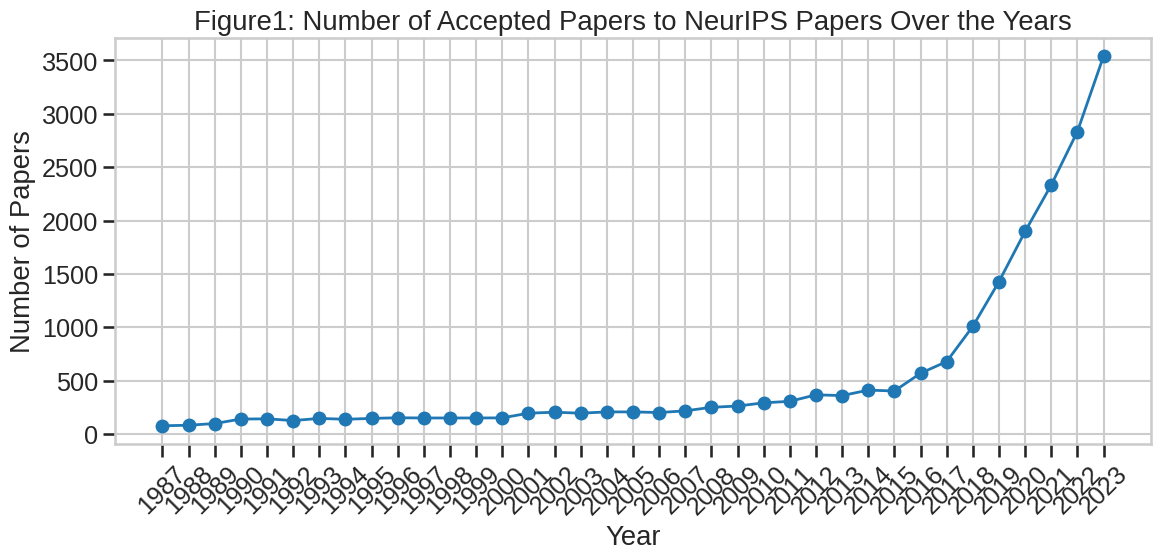

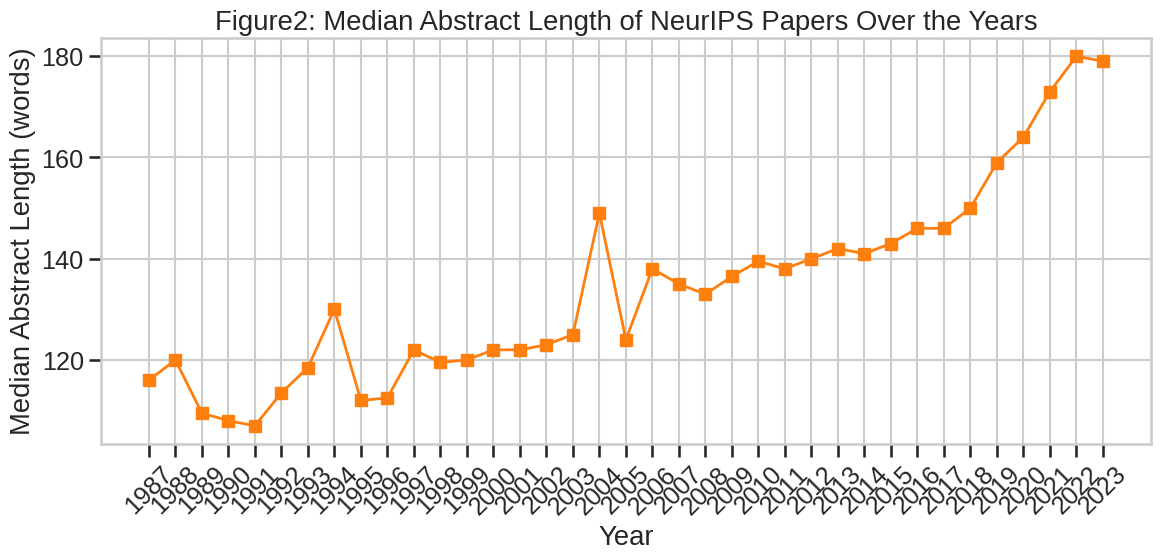

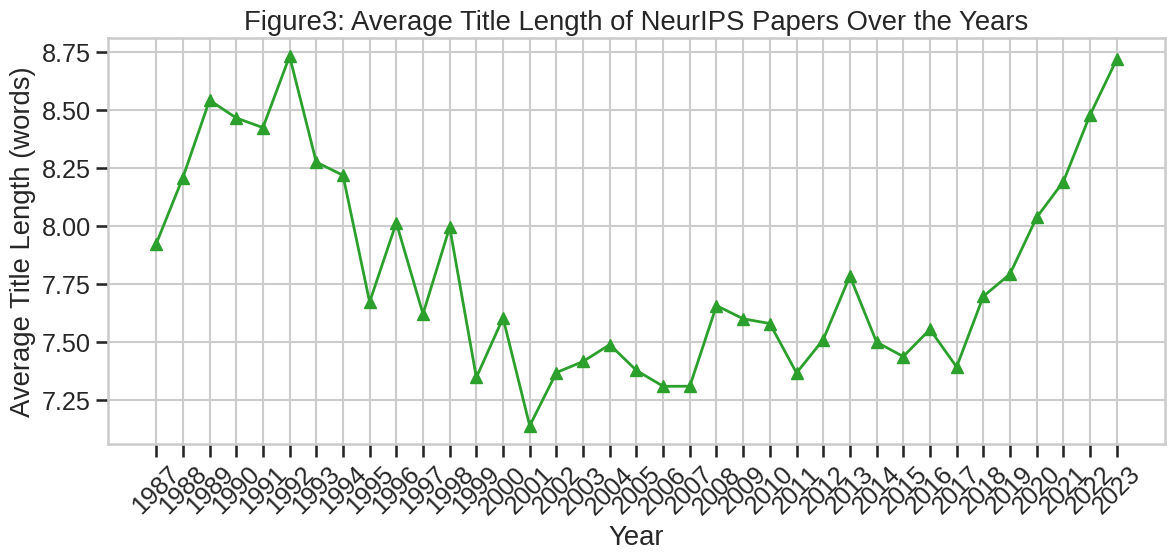

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a publication-quality style (using seaborn settings for a ggplot2-like feel)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("talk", font_scale=1.1)
# --- Explore Potentially Inappropriate Papers by Length ---
# (Papers with title length < 2 OR abstract length < 5)
short_texts = df[(df['abstract_length'] < 5)]

# --- Remove Papers with Abstract Length Less Than 5 ---
df_clean = df[df['abstract_length'] >= 5].copy()

# ================================
# Summary Statistics (Cleaned Data)
# ================================

# # Total number of papers after filtering
total_papers = len(df_clean)
# print(f"\n**Total Number of Papers:** {total_papers}\n")

# # Count of papers per year
papers_per_year = df_clean['year'].value_counts().sort_index()
# print("**Papers Per Year:**\n")
# print(papers_per_year.to_markdown())

# # Average abstract length per year (in words)
abstract_stats = df_clean.groupby('year')['abstract_length'].agg(['mean', 'median', 'min', 'max']).reset_index()
# print("\n**Abstract Length Statistics per Year (in words, after filtering):**\n")
# print(abstract_stats.to_markdown(index=False))

# ================================
# Publication-Quality Figures (Cleaned Data)
# ================================

# 1. Trend of Number of Papers Over the Years
plt.figure(figsize=(12, 6))
plt.plot(papers_per_year.index, papers_per_year.values, marker='o', linestyle='-', linewidth=2)
plt.xlabel("Year")
plt.ylabel("Number of Papers")
plt.title("Figure1: Number of Accepted Papers to NeurIPS Papers Over the Years")
plt.xticks(papers_per_year.index, rotation=45)
plt.tight_layout()
plt.show()

# 2. Median Abstract Length Over the Years
avg_abs_length = df_clean.groupby('year')['abstract_length'].median()
plt.figure(figsize=(12, 6))
plt.plot(avg_abs_length.index, avg_abs_length.values, marker='s', linestyle='-', linewidth=2, color='tab:orange')
plt.xlabel("Year")
plt.ylabel("Median Abstract Length (words)")
plt.title("Figure2: Median Abstract Length of NeurIPS Papers Over the Years")
plt.xticks(avg_abs_length.index, rotation=45)
plt.tight_layout()
plt.show()

# ================================
# Additional Preliminary Results (Cleaned Data)
# ================================

# --- Title Length Analysis ---
title_stats = df_clean.groupby('year')['title_length'].agg(['mean', 'median', 'min', 'max']).reset_index()
# print("\n**Title Length Statistics per Year (in words):**\n")
# print(title_stats.to_markdown(index=False))

avg_title_length = df_clean.groupby('year')['title_length'].mean()
plt.figure(figsize=(12, 6))
plt.plot(avg_title_length.index, avg_title_length.values, marker='^', linestyle='-', linewidth=2, color='tab:green')
plt.xlabel("Year")
plt.ylabel("Average Title Length (words)")
plt.title("Figure3: Average Title Length of NeurIPS Papers Over the Years")
plt.xticks(avg_title_length.index, rotation=45)
plt.tight_layout()
plt.show()

# --- Missing Abstract Analysis ---
df_clean['missing_abstract'] = df_clean['abstract'].isna() | (df_clean['abstract'].str.strip() == "")
missing_abstracts = df_clean.groupby('year')['missing_abstract'].sum().reset_index()
# print("\n**Missing Abstracts Count per Year:**\n")
# print(missing_abstracts.to_markdown(index=False))


## 3 Results

In this section, we report preliminary findings from our exploratory data analysis, focusing on publication trends and textual characteristics of accepted NeurIPS papers from 1987 to 2023.

### 3.1 Data Quality Considerations
During data preprocessing, we identified several papers with anomalously short abstracts or missing abstract content entirely. Examples of these cases are illustrated in Table 1. Early years, in particular, contained numerous entries marked "Abstract Unavailable," which were systematically removed from subsequent analyses to maintain data integrity. This filtering ensured that the subsequent embedding-based analyses and modeling were based on high-quality textual data.


### 3.2 Trends in Publication Volume
Figure 1 illustrates the annual number of accepted NeurIPS papers. The data reveal a significant increase in the volume of accepted papers, especially notable from approximately 2010 onward. Prior to this period, the conference accepted fewer than 500 papers annually, whereas recent years have seen exponential growth, surpassing 3,500 accepted papers by 2023. This increase likely reflects heightened global research activity and broader community engagement in machine learning and artificial intelligence.

### 3.3 Trends in Title Length
Figure 2 shows the average title length, measured in number of words, across the studied timeframe. The average title length demonstrates modest fluctuations, remaining consistently within a range of approximately 7 to 9 words. This stability suggests a relatively unchanged practice in summarizing research content concisely within paper titles, despite the overall increase in publication volume and complexity.

### 3.4 Trends in Abstract Length
Figure 3 presents the median abstract length (in words) from 1987 to 2023. A clear upward trajectory is evident, particularly noticeable over the past two decades. Initially averaging around 120 words in the early years, the median length of abstracts has gradually increased to approximately 180 words in recent submissions. This trend may reflect the increasing complexity of research questions addressed, the growing sophistication of experimental methodologies, or evolving standards in scientific communication, requiring more comprehensive abstracts.

These preliminary explorations highlight significant temporal shifts in both publication volumes and textual characteristics of NeurIPS papers. In the subsequent sections, we extend our analysis using embedding-based methods to further elucidate evolving thematic trends within the conference.


In [1]:
# ----------------------------------------------------------------------------------
# 📦 1. Install & quick-setup  (run once per session)
# ----------------------------------------------------------------------------------
!pip install -q --upgrade \
    transformers adapters \
    faiss-cpu umap-learn fast-hdbscan \
    datamapplot matplotlib \
    spacy==3.8.2 inflection tqdm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.6/30.6 MB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.3/289.3 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 133.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.3/31.3 MB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.9/150.9 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 136.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 73.0 MB/s eta 0:00:00


In [2]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 108.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [3]:
# ----------------------------------------------------------------------------------
# 2. Set paths & parameters  (EDIT if your files live elsewhere)
# ----------------------------------------------------------------------------------
CSV_PATH      = "/content/neurips_papers_1987_2023_parallel_updated.csv"
OUTPUT_DIR    = "/content/neurips_trend_outputs"   # or "/content"
HTML_FILENAME = "embedding_analysis_landscape.html"

from collections import Counter, defaultdict
from tqdm import tqdm, trange
import os, warnings, re, functools, torch, numpy as np, pandas as pd
os.makedirs(OUTPUT_DIR, exist_ok=True)
DEVICE        = "cuda" if torch.cuda.is_available() else "cpu"
SEED          = 28


In [4]:
# ----------------------------------------------------------------------------------
# 3. Utility – sentence-embedding helper (SPECTER2 via adapters)
# ----------------------------------------------------------------------------------
from transformers import AutoTokenizer
from adapters import AutoAdapterModel

EMBED_MODEL = "allenai/specter2_base"    # backbone
ADAPTER_ID  = "allenai/specter2"

tokenizer = AutoTokenizer.from_pretrained(EMBED_MODEL)
model     = AutoAdapterModel.from_pretrained(EMBED_MODEL)
model.load_adapter(ADAPTER_ID,
                   source="hf",
                   load_as="specter2_adapter",
                   set_active=True)
model.to(DEVICE).eval()


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/453 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/228k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/717k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

...

adapter_config.json:   0%|          | 0.00/1.03k [00:00<?, ?B/s]

.gitattributes:   0%|          | 0.00/1.48k [00:00<?, ?B/s]

README.md:   0%|          | 0.00/9.77k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

BertAdapterModel(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(31090, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttentionWithAdapters(
              (query): LoRALinearTorch(
                in_features=768, out_features=768, bias=True
                (loras): ModuleDict()
              )
              (key): LoRALinearTorch(
                in_features=768, out_features=768, bias=True
                (loras): ModuleDict()
              )
              (value): LoRALinearTorch(
                in_features=768, out_features=768, bias=True
                (loras): ModuleDict()
              

In [8]:
import os
import numpy as np
import pandas as pd
import faiss, spacy, inflection, umap
from tqdm import tqdm, trange
from fast_hdbscan import HDBSCAN
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer

# ---------- PATHS & CONSTANTS ----------
CACHE_PICKLE = "/content/preprocessed_cache.pkl"   # change if desired
UMAP_PARAMS  = dict(n_neighbors=15, min_dist=0.0, random_state=SEED)
HDBSCAN_PARAMS = dict(min_cluster_size=15)

# ---------- PIPELINE ----------
def preprocess_pipeline(csv_path,
                        turbo=True,
                        max_clusters=50,
                        k_nn=5,
                        cache_path=CACHE_PICKLE):
    """
    Heavy step: SPECTER2 embeddings → UMAP 2-D → HDBSCAN → k-NN outlier fix
    → TF-IDF topics.  All CPU.  Returns (df, emb2d, labels, topics).

    If cache_path exists, loads the tuple directly.
    """
    if cache_path and os.path.exists(cache_path):
        return pd.read_pickle(cache_path)

    # 1) ---------- Load data ----------
    df = pd.read_csv(csv_path)
    df["abstract"] = df["abstract"].fillna("")
    texts = (df["title"] + ". " + df["abstract"]).tolist()

    # 2) ---------- Embeddings ----------
    vecs = embed_sentences(texts,
                           batch=256 if turbo else 32,
                           use_fp16=turbo)

    # 3) ---------- 2-D UMAP ----------
    emb2d = umap.UMAP(**UMAP_PARAMS).fit_transform(vecs)

    # 4) ---------- HDBSCAN ----------
    labels = HDBSCAN(**HDBSCAN_PARAMS).fit_predict(emb2d)
    inlier = labels != -1

    # optional consolidation if too many tiny clusters
    if np.unique(labels[inlier]).size > max_clusters:
        means = np.vstack([emb2d[labels == c].mean(0)
                           for c in np.unique(labels[inlier])])
        newlab = KMeans(max_clusters, random_state=SEED).fit_predict(means)
        mapping = dict(zip(np.unique(labels[inlier]), newlab))
        labels  = np.array([mapping.get(l, -1) for l in labels])

    # 5) ---------- FAISS k-NN (CPU) to re-label outliers ----------
    dim   = emb2d.shape[1]          # = 2
    index = faiss.IndexFlatL2(dim)
    index.add(emb2d[inlier].astype("float32"))
    _, nn = index.search(emb2d[~inlier].astype("float32"), k_nn)
    labels[~inlier] = np.array([
        np.bincount(labels[inlier][nbr]).argmax() for nbr in nn
    ])

    df["cluster"] = labels

    # 6) ---------- n-gram extraction ----------
    nlp  = spacy.load("en_core_web_sm", disable=["parser", "ner", "lemmatizer"])
    stop = nlp.Defaults.stop_words

    def ngrams(doc, n):
        toks = [t for t in doc if t.pos_ in {"NOUN", "PROPN"} and t.text not in stop]
        return ["_".join(inflection.singularize(t.text.lower())
                         for t in toks[i:i+n])
                for i in range(len(toks)-n+1)]

    grams_per_doc = []
    for doc in tqdm(nlp.pipe(texts,
                             batch_size=100,
                             n_process=os.cpu_count()),
                    total=len(texts), desc="↳ N-gram"):
        grams_per_doc.append(ngrams(doc,2) + ngrams(doc,1))

    # 7) ---------- TF-IDF topics ----------
    cluster_ids = sorted(np.unique(labels))
    corp = [" ".join(" ".join(g)
                     for g, lab in zip(grams_per_doc, labels)
                     if lab == cid)
            for cid in cluster_ids]

    vectorizer = TfidfVectorizer()
    tfidf  = vectorizer.fit_transform(corp).toarray()
    words  = vectorizer.get_feature_names_out()

    top_kw = {cid: " ".join(words[tfidf[i].argsort()[-3:][::-1]])
              for i, cid in enumerate(cluster_ids)}
    topics = [top_kw[l] for l in labels]
    df["topic"] = topics

    # 8) ---------- cache & return ----------
    bundle = (df, emb2d, labels, topics)
    if cache_path:
        pd.to_pickle(bundle, cache_path)
    return bundle

def embed_sentences(sentences, batch=256, max_len=512, use_fp16=True):
    """
    Return (N × 768) embeddings.  On A100 you can safely push batch=256 and fp16.
    """
    if isinstance(sentences, str):
        sentences = [sentences]

    torch.backends.cuda.matmul.allow_tf32 = True
    model_dtype = torch.float16 if (use_fp16 and DEVICE == "cuda") else torch.float32
    model.to(dtype=model_dtype)

    idx_sort = np.argsort([-len(s) for s in sentences])
    sent_sorted = [sentences[i] for i in idx_sort]
    vecs = []

    for i in trange(0, len(sent_sorted), batch, desc="↳ Encoding", leave=False):
        toks = tokenizer.batch_encode_plus(
            sent_sorted[i:i+batch],
            padding="longest",
            truncation=True,
            max_length=max_len,
            return_tensors="pt"
        ).to(DEVICE)

        with torch.autocast(device_type="cuda", enabled=use_fp16):
            with torch.no_grad():
                out = model(**toks).last_hidden_state[:, 0, :]        # CLS

        vecs.extend(out.cpu())

    vecs = [vecs[i] for i in np.argsort(idx_sort)]
    return torch.stack(vecs).numpy().astype("float32")               # keep downstream happy

In [13]:
import numpy as np, inspect, matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from matplotlib.colors import to_rgb
import datamapplot
import os, numpy as np, pandas as pd, faiss, spacy, inflection, umap, datamapplot
from tqdm import tqdm
from fast_hdbscan import HDBSCAN
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from scipy.stats import linregress
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb


def rmse(y_true, y_pred):
    from sklearn.metrics import mean_squared_error as _mse
    return (_mse(y_true, y_pred, squared=False)
            if "squared" in inspect.signature(_mse).parameters
            else np.sqrt(_mse(y_true, y_pred)))

def _slope(y_pred, x):
    return linregress(x, y_pred).slope
# mapping of model names → sklearn estimators
_MODEL_ZOO = {
    "linear"        : LinearRegression(),
    "ridge"         : Ridge(alpha=1.0, random_state=SEED),
    "random_forest" : RandomForestRegressor(n_estimators=200,
                                            max_depth=None,
                                            random_state=SEED),
    "gboost"        : GradientBoostingRegressor(random_state=SEED),
}



def run_growth_model(model_name,
                     pre_df, emb2d, labels, topics,
                     html_out, growth_years=(1987,2024), test_size=0.2):
    """
    Takes pre-computed artefacts and fits ONE growth-rate model.
    Produces an HTML plot & returns stats dict.
    """
    years_all = np.arange(growth_years[0], growth_years[1]+1).reshape(-1,1)
    cluster_ids = sorted(np.unique(labels))

    proto = _MODEL_ZOO[model_name.lower()]
    growth, stats = {}, {}

    for cid in cluster_ids:
        y = np.array([((labels == cid) & (pre_df["year"] == yr)).sum()
                      for yr in years_all.flatten()])
        X_tr, X_te, y_tr, y_te = train_test_split(years_all, y,
                                                 test_size=test_size,
                                                 shuffle=False)
        mdl = proto.__class__(**proto.get_params()).fit(X_tr, y_tr)
        y_pred = mdl.predict(X_te)
        R2  = r2_score(y_te, y_pred) if len(y_te) >= 2 else np.nan
        RM  = rmse(y_te, y_pred)
        slope = linregress(years_all.flatten(),
                           mdl.predict(years_all)).slope
        growth[cid] = slope
        stats[cid]  = {"model": model_name, "R2": R2, "RMSE": RM, "slope": slope}

    # colours by growth slope
    vmax = max(abs(v) for v in growth.values()) or 1
    cmap = plt.get_cmap("coolwarm")
    colours = [to_rgb(cmap((growth[l]+vmax)/(2*vmax))) for l in labels]

    # hover text
    hover = [f"<b>{row.title}</b><br>Year: {row.year}<br>"
             f"Topic: {row.topic}<br>Slope: {growth[row.cluster]:.3f}"
             for _, row in pre_df.iterrows()]

    datamapplot.create_interactive_plot(
        emb2d, [t.replace("_"," ") for t in topics],
        hover_text=hover,
        marker_color_array=colours,
        marker_size_array=2,
        enable_search=True
    ).save(html_out)

    print(f"✨ {model_name} plot → {html_out}")
    return stats, growth


In [10]:
# heavy step – do ONCE
prep_df, emb2d, labels, topics = preprocess_pipeline(CSV_PATH, turbo=True)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
↳ N-gram: 100%|██████████| 20286/20286 [02:57<00:00, 114.29it/s]


In [14]:

# light steps – run as many as you like
models = ["linear", "ridge", "random_forest", "gboost"]
all_stats = {}
for m in models:
    html_file = os.path.join(OUTPUT_DIR, f"embedding_{m}.html")
    stats, slopes = run_growth_model(m,
                                     prep_df, emb2d, labels, topics,
                                     html_out=html_file,
                                     growth_years=(1987,2024),
                                     test_size=0.2)
    all_stats[m] = stats            # collect if you need a big comparison table


✨ linear plot → /content/neurips_trend_outputs/embedding_linear.html
✨ ridge plot → /content/neurips_trend_outputs/embedding_ridge.html
✨ random_forest plot → /content/neurips_trend_outputs/embedding_random_forest.html
✨ gboost plot → /content/neurips_trend_outputs/embedding_gboost.html


In [35]:
import pandas as pd, numpy as np

def summarize_fit(all_stats: dict) -> pd.DataFrame:
    """
    Build one row per model with mean / median R² and RMSE
    (ignores clusters where R² is nan because the test fold had <2 samples).
    """
    rows = []
    for model, clust_dict in all_stats.items():
        r2   = [v["R2"]   for v in clust_dict.values() if not np.isnan(v["R2"])]
        rmse = [v["RMSE"] for v in clust_dict.values() if not np.isnan(v["RMSE"])]
        rows.append({
            "model"      : model,
            "mean_R2"    : np.round(np.nanmean(r2),   3) if r2 else np.nan,
            "median_R2"  : np.round(np.nanmedian(r2), 3) if r2 else np.nan,
            "mean_RMSE"  : np.round(np.nanmean(rmse), 3) if rmse else np.nan,
            "median_RMSE": np.round(np.nanmedian(rmse),3) if rmse else np.nan,
            "n_clusters" : len(r2)
        })
    return (pd.DataFrame(rows)
              .set_index("model")
              .sort_values("mean_R2", ascending=False))

# ▶ generate and display the summary
summary_8724 = summarize_fit(all_stats)
display(Markdown("**Table 2.** Comparative performance of four regression models when the growth‐rate task is trained on NeurIPS data from 1987 to 2024 and evaluated on a 20 % chronological hold-out.  Gradient boosting (gboost) attains the lowest mean RMSE and the least-negative median R², indicating better predictive accuracy than random-forest and linear baselines over the full 37-year window."))
summary_8724


**Table 2.** Comparative performance of four regression models when the growth‐rate task is trained on NeurIPS data from 1987 to 2024 and evaluated on a 20 % chronological hold-out.  Gradient boosting (gboost) attains the lowest mean RMSE and the least-negative median R², indicating better predictive accuracy than random-forest and linear baselines over the full 37-year window.

,mean_R2,median_R2,mean_RMSE,median_RMSE,n_clusters
model,,,,,
gboost,-0.917,-0.864,33.944,21.293,50
random_forest,-0.967,-1.062,34.633,22.557,50
ridge,-2.907,-1.126,36.415,24.730,50
linear,-2.910,-1.126,36.414,24.735,50


In [16]:
# light steps – run as many as you like
models = ["linear", "ridge", "random_forest", "gboost"]
all_stats_2000_2024 = {}
for m in models:
    html_file = os.path.join(OUTPUT_DIR, f"embedding_{m}_2000_2024.html")
    stats, slopes = run_growth_model(m,
                                     prep_df, emb2d, labels, topics,
                                     html_out=html_file,
                                     growth_years=(2000,2024),
                                     test_size=0.2)
    all_stats_2000_2024[m] = stats            # collect if you need a big comparison table



✨ linear plot → /content/neurips_trend_outputs/embedding_linear_2000_2024.html
✨ ridge plot → /content/neurips_trend_outputs/embedding_ridge_2000_2024.html
✨ random_forest plot → /content/neurips_trend_outputs/embedding_random_forest_2000_2024.html
✨ gboost plot → /content/neurips_trend_outputs/embedding_gboost_2000_2024.html


In [36]:
summary_0024 = summarize_fit(all_stats_2000_2024)
display(Markdown("**Table 3.** Model performance when the analysis window is restricted to papers published between 2000 and 2024.  Predictive errors drop for all methods, and gradient boosting again achieves the best combination of RMSE and R², suggesting that non-linear ensemble approaches capture recent topic dynamics more effectively than linear alternatives."))

summary_0024

**Table 3.** Model performance when the analysis window is restricted to papers published between 2000 and 2024.  Predictive errors drop for all methods, and gradient boosting again achieves the best combination of RMSE and R², suggesting that non-linear ensemble approaches capture recent topic dynamics more effectively than linear alternatives.

,mean_R2,median_R2,mean_RMSE,median_RMSE,n_clusters
model,,,,,
gboost,-0.529,-0.418,30.875,21.435,50
random_forest,-0.570,-0.446,32.484,22.317,50
ridge,-1.081,-1.062,37.372,25.449,50
linear,-1.081,-1.064,37.366,25.462,50


In [18]:
# -----------------------------------------------------------
# FILENAME: make_gboost_figures.py        (reduced: no Figure 1)
# PURPOSE : 2 interactive plots driven by a GBoost model
# -----------------------------------------------------------
import os, json, numpy as np
import plotly.express as px
import plotly.graph_objs as go
from plotly.offline import plot
from scipy.stats import linregress          # already used upstream

# ---------- PARAMETERS ----------
MODEL_NAME  = "gboost"            # must match the key in _MODEL_ZOO
OUTPUT_DIR  = "docs"              # GitHub Pages serves everything here
os.makedirs(OUTPUT_DIR, exist_ok=True)

FIG2_OUT = os.path.join(OUTPUT_DIR, "fig2_growth_lines.html")
FIG3_OUT = os.path.join(OUTPUT_DIR, "fig3_topic_slopes.html")

FIG2_TITLE = ("Figure 1 — Actual publication counts (dots) and "
              "GBoost fit (lines) for the five fastest-growing clusters")
FIG3_TITLE = ("Figure 2 — Top-20 cluster topics ranked by "
              "GBoost growth slope (papers / year)")

# ------------------------------------------------------------------
# 1) Run the growth-rate model once and keep the per-cluster slopes
# ------------------------------------------------------------------
stats_gb, slope_gb = run_growth_model(
    MODEL_NAME,
    prep_df,
    emb2d,
    labels,
    topics,
    os.path.join(OUTPUT_DIR, "tmp_gboost_embed.html"),  # disposable
    (1987, 2024),
    0.2
)
try:
    os.remove(os.path.join(OUTPUT_DIR, "tmp_gboost_embed.html"))
except OSError:
    pass


# ------------------------------------------------------------------
# 2) FIGURE 1 – Year-by-year counts + GBoost fit for top-5 clusters
# ------------------------------------------------------------------
years = np.arange(2000, 2024)
top5  = sorted(slope_gb, key=slope_gb.get, reverse=True)[:5]

traces = []
for cid in top5:
    # actual yearly counts
    yc = (prep_df.loc[labels == cid, "year"]
                  .value_counts()
                  .reindex(years, fill_value=0)
                  .sort_index())

    # refit a tiny GBoost regressor just for plotting
    proto = _MODEL_ZOO[MODEL_NAME].__class__(**_MODEL_ZOO[MODEL_NAME].get_params())
    mdl   = proto.fit(years.reshape(-1, 1), yc.values)
    yhat  = mdl.predict(years.reshape(-1, 1))

    cname  = f"Cluster {cid}"
    colour = px.colors.qualitative.Plotly[cid % 10]
    traces.append(go.Scatter(x=years, y=yc,   mode="markers",
                             name=f"{cname} (actual)", marker=dict(color=colour)))
    traces.append(go.Scatter(x=years, y=yhat, mode="lines",
                             name=f"{cname} (GBoost fit)", line=dict(color=colour)))

fig2 = go.Figure(traces)
fig2.update_layout(
    title=FIG2_TITLE,
    xaxis_title="Year",
    yaxis_title="Number of papers",
    hovermode="x unified"
)
plot(fig2, filename=FIG2_OUT, auto_open=False)
print(f"✅  saved {FIG2_OUT}")


# ------------------------------------------------------------------
# 3) FIGURE 2 – Bar chart of growth slopes (top-20 clusters)
# ------------------------------------------------------------------
# pick one representative topic string per cluster
cluster_topic = {}
for lab, top in zip(labels, topics):
    cluster_topic.setdefault(lab, top.replace("_", " "))

slope_items   = sorted(slope_gb.items(), key=lambda kv: kv[1], reverse=True)[:20]
topics_sorted = [cluster_topic[cid] for cid, _ in slope_items]
slopes_sorted = [s for _, s in slope_items]

fig3 = go.Figure(
    go.Bar(x=slopes_sorted, y=topics_sorted, orientation="h",
           marker=dict(opacity=0.8))
)
fig3.update_layout(
    title=FIG3_TITLE,
    xaxis_title="Growth slope (papers / year)",
    yaxis_title="Cluster topic",
    yaxis=dict(autorange="reversed")   # highest bar on top
)
plot(fig3, filename=FIG3_OUT, auto_open=False)
print(f"✅  saved {FIG3_OUT}")


# ------------------------------------------------------------------
# 4) Optional manifest for auto-linking
# ------------------------------------------------------------------
with open(os.path.join(OUTPUT_DIR, "manifest.json"), "w") as f:
    json.dump({
        "fig1": os.path.basename(FIG2_OUT),   # renumbered for publication
        "fig2": os.path.basename(FIG3_OUT),
        "model": MODEL_NAME
    }, f, indent=2)
print("🎉  Both interactive plots are ready for GitHub Pages!")


✨ gboost plot → docs/tmp_gboost_embed.html
✅  saved docs/fig2_growth_lines.html
✅  saved docs/fig3_topic_slopes.html
🎉  Both interactive plots are ready for GitHub Pages!



### 3.5 Performance of Trend-prediction Models  

Tables 2 and 3 compare four regression approaches—ordinary least squares ("linear"), ridge regression, random forest, and gradient boosting (gboost)—on predicting the number of NeurIPS papers per topic cluster annually.

Gradient boosting combines multiple shallow decision trees, iteratively correcting the errors (residuals) of previous trees. This method is particularly suited to capturing non-linear or abrupt trends, such as sudden bursts of research activity after periods of relative inactivity—patterns frequently observed in research data that linear models struggle to capture.

Across both analysis periods (1987–2024 and 2000–2024), gradient boosting consistently achieves the lowest prediction error and the highest (least-negative) R² values. Due to its superior performance, we rely on gradient boosting to inform subsequent visualizations and interpretations of topic growth trajectories.

### 3.6 Topic Landscape and Growth Patterns  

#### 3.6.1 Long-term Trends (1987-2024)  

The embedding visualization represents each NeurIPS paper as a single dot within a two-dimensional UMAP projection. Colors reflect the growth trends computed using gradient boosting from the entire dataset spanning 37 years (red indicates increasing popularity, blue indicates decreasing popularity).

The most rapidly expanding topic cluster over this period is broadly labelled as "algorithm problem method," centrally positioned within the visualization. This suggests that the core methodologies and algorithmic frameworks have consistently driven research interest across multiple decades. This cluster captures foundational methods such as optimization techniques, learning algorithms, and general computational approaches, underscoring the sustained focus on methodological innovations as a key driver of progress within NeurIPS.

Conversely, topic clusters related to early-stage neural computation and biological neuron simulation—such as "neuron simulation" and "PDE network"—are predominantly blue, indicating diminished interest over time. This shift likely reflects a transition from foundational neural simulation toward more sophisticated machine learning architectures.

#### 3.6.2 Recent Trends (2020-2024)  

When focusing solely on recent years, the strongest area of growth distinctly shifts towards "reinforcement learning/policy learning." This cluster appears prominently red, clearly reflecting intensified research interest driven by notable breakthroughs and practical applications in reinforcement learning (RL). Indeed, since seminal advancements such as AlphaGo (2016), RL has increasingly become a central theme in contemporary machine learning research, influencing a broad range of real-world applications.

Meanwhile, traditionally active areas like generic neural network training and simpler bandit algorithm formulations have slowed, evident by their pale coloration, suggesting a relative decrease in submissions to NeurIPS. The fading interest in generic methods is likely due to specialization and the emergence of dedicated conferences or subfields elsewhere in the academic landscape.

#### 3.6.3 Interpretation and Insights  

Integrating both the long-term (1987-2024) and short-term (2020-2024) perspectives reveals a notable evolution in research priorities. Historically, the most influential and consistently expanding area within NeurIPS has been general algorithmic and methodological research—reflecting a broad community focus on developing universal frameworks and optimization techniques applicable to various problem domains.

More recently, the emphasis has noticeably shifted towards reinforcement learning and policy-driven methodologies, reflecting a contemporary trend toward application-oriented and real-world impactful research. This shift aligns with broader developments in artificial intelligence research, marked by increased investments in RL applications such as robotics, strategic games, autonomous systems, and decision-making frameworks.


## 4.Conclusions and Summary

This study explored the evolution of research themes and publication characteristics within NeurIPS from 1987 to 2024, revealing substantial growth in overall participation and significant shifts in research interests. Our findings highlight several key insights into the dynamics of the NeurIPS community:

- **Publication Growth**: The exponential increase in the volume of accepted papers over the years underscores NeurIPS's pivotal role as a central hub for machine learning research. This growth likely reflects both increased global research activity in artificial intelligence and the expanded accessibility of the conference itself.

- **Evolution of Paper Content**: Median abstract lengths have steadily increased, indicating a trend towards more detailed, nuanced, and comprehensive descriptions. This change could reflect rising methodological complexity or heightened expectations for rigorous validation and reproducibility.

- **Topic Dynamics and Embedding Analysis**: Embedding-based analysis identified long-term and recent shifts in research interests. Historically, general algorithmic and methodological frameworks dominated, emphasizing fundamental, broad applicability. However, recent trends prominently feature reinforcement learning, aligning closely with advancements in real-world applications and high-impact practical research. This demonstrates the community's responsiveness to both theoretical innovations and pressing real-world challenges.

- **Predictive Model Insights**: Among the evaluated regression methods—linear regression, ridge regression, random forest, and gradient boosting—the gradient boosting model consistently provided superior predictive accuracy in tracking topic trajectories, effectively capturing non-linear dynamics and sudden shifts in topic popularity.

### 4.1 Limitations

Despite these insights, several limitations merit acknowledgment:

- **Data Completeness and Quality**: Our analysis relied solely on abstracts and titles. The absence of full-text analysis or additional metadata (e.g., author affiliations, citation counts) limits the depth and context of our topic modeling.

- **Temporal Analysis Constraints**: The model's predictive performance, while superior with gradient boosting, remained modest (negative R² values), indicating inherent variability and complexity in forecasting research trends purely from past publication counts.

- **Embedding Dimensionality and Interpretation**: The embeddings capture semantic similarities effectively, but two-dimensional visualizations inevitably lose information, potentially oversimplifying relationships among topics.

### 4.2 Future Directions

Future work could address these limitations by integrating additional data sources such as citation information, co-authorship networks, or funding patterns. Moreover, incorporating advanced temporal models, such as deep sequence models or time-series-specific neural architectures, may provide richer insights into the trajectory of scientific topics.

Overall, this analysis highlights both the growth and specialization trends in NeurIPS research, offering a comprehensive view into how machine learning research continues to adapt and evolve in response to theoretical advancements and practical demands.
